In [245]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [246]:
columns = [
    "Sample_Code_Number",
    "Clump_Thickness",
    "Uniformity_of_Cell_Size",
    "Uniformity_of_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

In [247]:
df = pd.read_csv(
    "breast-cancer-wisconsin.data",
    names=columns,
    header=None
)

In [248]:
print("First Five Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)



First Five Rows
   Sample_Code_Number  Clump_Thickness  Uniformity_of_Cell_Size  \
0             1000025                5                        1   
1             1002945                5                        4   
2             1015425                3                        1   
3             1016277                6                        8   
4             1017023                4                        1   

   Uniformity_of_Cell_Shape  Marginal_Adhesion  Single_Epithelial_Cell_Size  \
0                         1                  1                            2   
1                         4                  5                            7   
2                         1                  1                            2   
3                         8                  1                            3   
4                         1                  3                            2   

  Bare_Nuclei  Bland_Chromatin  Normal_Nucleoli  Mitoses  Class  
0           1                3          

In [249]:

print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample_Code_Number           699 non-null    int64
 1   Clump_Thickness              699 non-null    int64
 2   Uniformity_of_Cell_Size      699 non-null    int64
 3   Uniformity_of_Cell_Shape     699 non-null    int64
 4   Marginal_Adhesion            699 non-null    int64
 5   Single_Epithelial_Cell_Size  699 non-null    int64
 6   Bare_Nuclei                  699 non-null    str  
 7   Bland_Chromatin              699 non-null    int64
 8   Normal_Nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Class                        699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB
None


In [250]:
print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
       Sample_Code_Number  Clump_Thickness  Uniformity_of_Cell_Size  \
count        6.990000e+02       699.000000               699.000000   
mean         1.071704e+06         4.417740                 3.134478   
std          6.170957e+05         2.815741                 3.051459   
min          6.163400e+04         1.000000                 1.000000   
25%          8.706885e+05         2.000000                 1.000000   
50%          1.171710e+06         4.000000                 1.000000   
75%          1.238298e+06         6.000000                 5.000000   
max          1.345435e+07        10.000000                10.000000   

       Uniformity_of_Cell_Shape  Marginal_Adhesion  \
count                699.000000         699.000000   
mean                   3.207439           2.806867   
std                    2.971913           2.855379   
min                    1.000000           1.000000   
25%                    1.000000           1.000000   
50%         

In [251]:
df.replace("?", np.nan, inplace=True)

df["Bare_Nuclei"] = pd.to_numeric(df["Bare_Nuclei"])
df["Bare_Nuclei"].isnull().sum()

df["Bare_Nuclei"]=df["Bare_Nuclei"].fillna(df["Bare_Nuclei"].median(), inplace=True)


/var/folders/g3/ktp9qbgn0r54hdqdwrc8wrjm0000gn/T/ipykernel_2968/177517194.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Bare_Nuclei"]=df["Bare_Nuclei"].fillna(df["Bare_Nuclei"].median(), inplace=True)


In [252]:
df.to_csv("breast_cancer_wisconsin.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [253]:
print(df["Bare_Nuclei"].dtype)

float64


In [254]:
print(df.describe())

       Sample_Code_Number  Clump_Thickness  Uniformity_of_Cell_Size  \
count        6.990000e+02       699.000000               699.000000   
mean         1.071704e+06         4.417740                 3.134478   
std          6.170957e+05         2.815741                 3.051459   
min          6.163400e+04         1.000000                 1.000000   
25%          8.706885e+05         2.000000                 1.000000   
50%          1.171710e+06         4.000000                 1.000000   
75%          1.238298e+06         6.000000                 5.000000   
max          1.345435e+07        10.000000                10.000000   

       Uniformity_of_Cell_Shape  Marginal_Adhesion  \
count                699.000000         699.000000   
mean                   3.207439           2.806867   
std                    2.971913           2.855379   
min                    1.000000           1.000000   
25%                    1.000000           1.000000   
50%                    1.000000     

In [255]:
# df=pd.read_csv("breast_cancer_wisconsin.csv")

Class
2    458
4    241
Name: count, dtype: int64


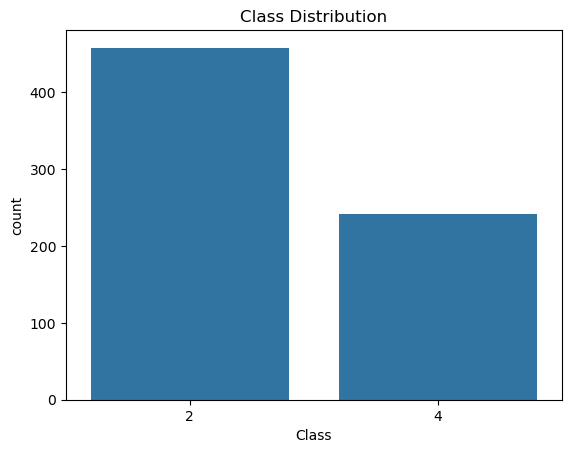

In [256]:
print(df["Class"].value_counts())

sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

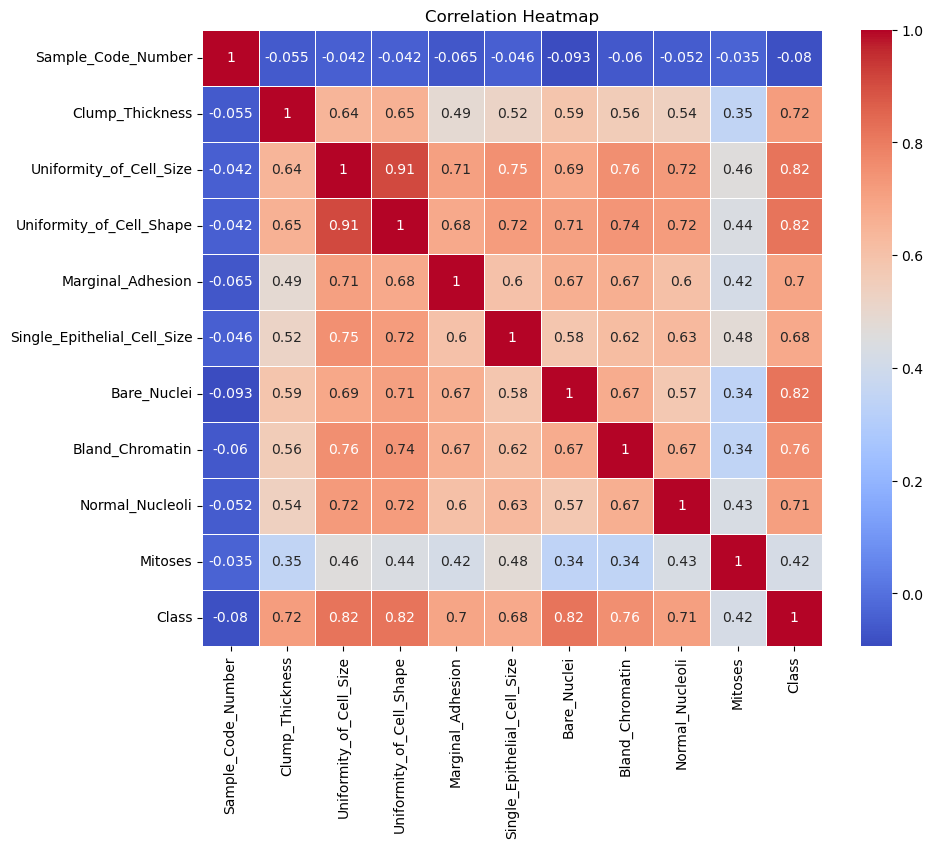

In [257]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [258]:
X = df.drop(["Sample_Code_Number", "Class"], axis=1)
y = df["Class"]

In [259]:
print(X["Bare_Nuclei"].isna().sum())

0


In [260]:
y = y.replace({
    2: 0,
    4: 1
})

print(y.value_counts())

Class
0    458
1    241
Name: count, dtype: int64


In [261]:
print((df["Bare_Nuclei"] == "?").sum())

0


In [262]:
X.isna().sum()


Clump_Thickness                0
Uniformity_of_Cell_Size        0
Uniformity_of_Cell_Shape       0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
dtype: int64

In [263]:
X.Bare_Nuclei.dropna(inplace=True)

In [264]:
X.isna().sum()


Clump_Thickness                0
Uniformity_of_Cell_Size        0
Uniformity_of_Cell_Shape       0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
dtype: int64

In [265]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [266]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [267]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
}

In [268]:
results = {}

best_model = None
best_accuracy = 0

for name, model in models.items():

    print(f"Training {name}")

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(f"Accuracy : {accuracy:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Save Best Model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_predictions = y_pred
        best_model_name = name

Training Logistic Regression
Accuracy : 0.9500

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        92
           1       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140

Training Support Vector Machine
Accuracy : 0.9571

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140

Training Decision Tree
Accuracy : 0.9286

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        92
           1       0.93      0

In [269]:
print(best_model_name, best_accuracy)

Support Vector Machine 0.9571428571428572


In [270]:
print("accuracy_score" , accuracy_score(y_test, best_predictions))


accuracy_score 0.9571428571428572


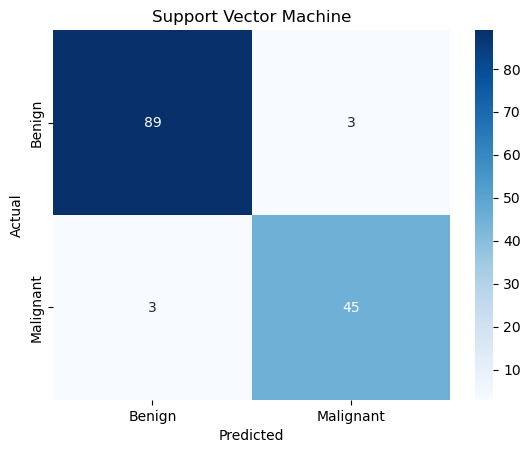

In [271]:
cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(best_model_name)
plt.show()

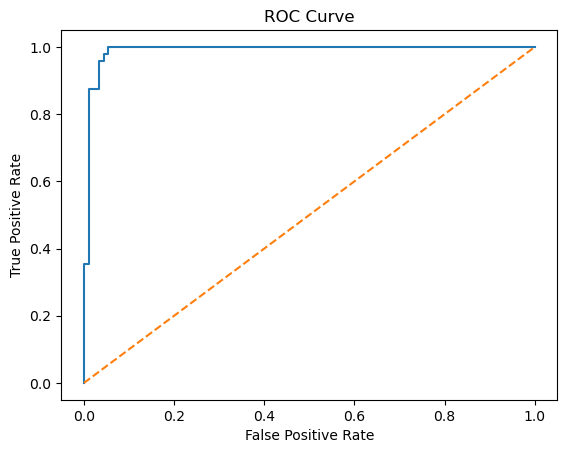

ROC AUC: 0.9895833333333334


In [272]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC AUC:", roc_auc_score(y_test, y_prob))

In [273]:
sample = [[10, 10, 10, 8, 10, 10, 9, 10, 7]]

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

if prediction[0] == 0:
    print("Result: Benign Tumor")
else:
    print("Result: Malignant Tumor")

Result: Malignant Tumor


/Users/sagunkumar/miniconda3/envs/biometric/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
